<a href="https://colab.research.google.com/github/SonalShukla-projects/Bankruptcy_Prediction_Company_ML_Project/blob/main/notebooks/04_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_DATASETS/clean_bankruptcy_data.csv"
df=pd.read_csv(path)

In [4]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

0.9633431085043989 1.0 0.0196078431372549 0.038461538461538464


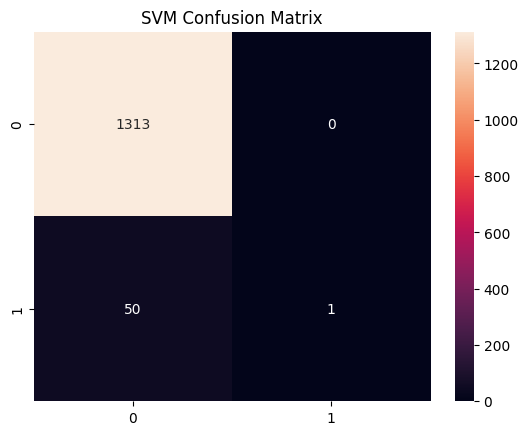

In [5]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(accuracy,precision,recall,f1)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

results = pd.DataFrame({
    "Model":["SVM"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1]
})

results.to_csv("svm_results.csv",index=False)